In [7]:
# %% [markdown]
# # Sunfire Ranking Algorithm Visualizer 🛰️
# Use this to tune your Relevance, Freshness, and Trust weightings.

# %%
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

In [8]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from parameters import *
from data import * 

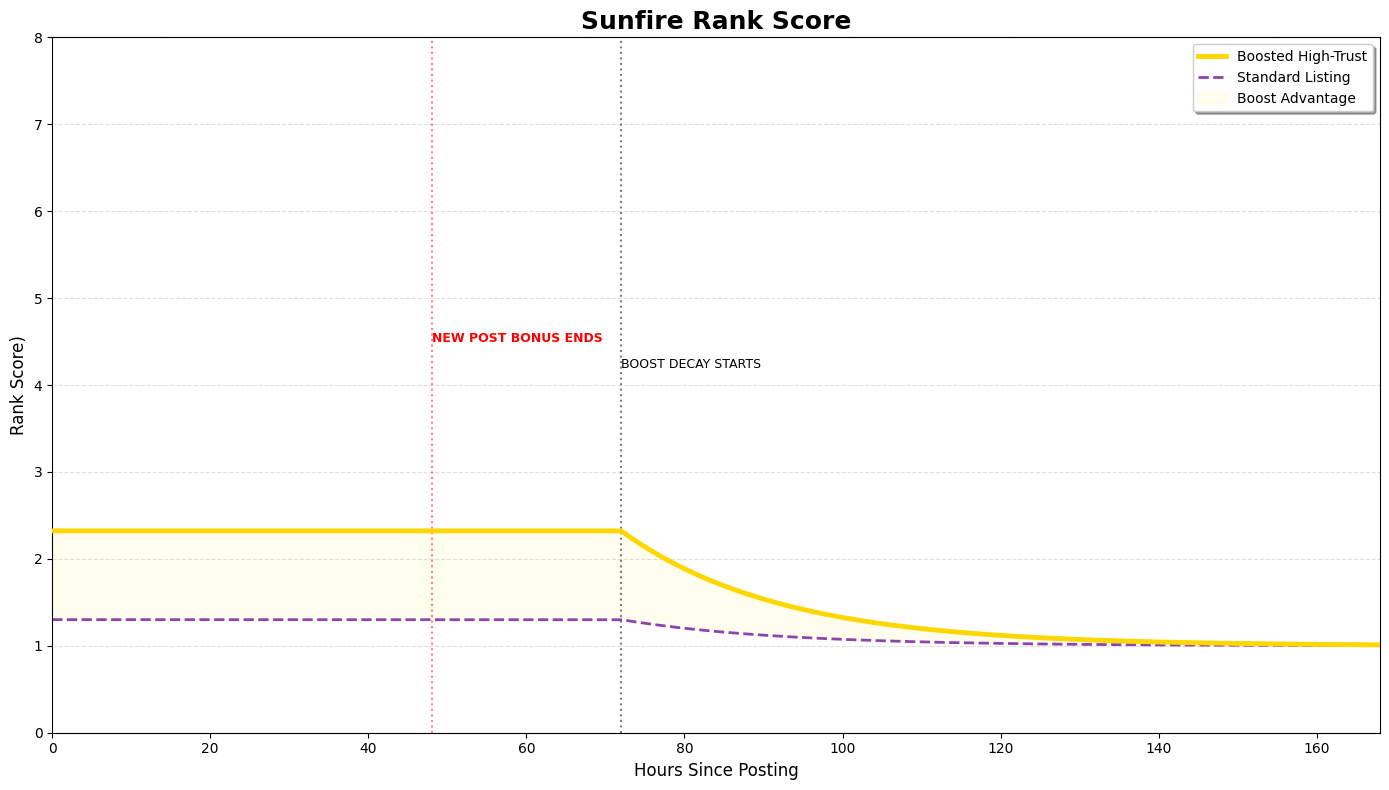

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from boost import *

hours = np.linspace(0, 168, 600) # 0 to 7 days
y_boosted = [calculate_boost(h, 10 + 10) for h in hours]
for h in hours:
    if h < 24:
        
y_standard = [calculate_boost(h, 1) for h in hours]

plt.figure(figsize=(14, 8), facecolor='white')

plt.plot(hours, y_boosted, label='Boosted High-Trust', color='#FFD700', lw=3.5, zorder=5)
plt.plot(hours, y_standard, label='Standard Listing', color='#8E44AD', linestyle='--', lw=2)

plt.fill_between(hours, y_boosted, y_standard, color='#FFF9C4', alpha=0.3, label='Boost Advantage')

# Annotations
plt.axvline(x=T_NEW_POST, color='red', ls=':', alpha=0.5)
plt.text(T_NEW_POST, 4.5, 'NEW POST BONUS ENDS', color='red', fontsize=9, fontweight='bold')
plt.axvline(x=BOOST_HOLD_HOURS, color='black', ls=':', alpha=0.5)
plt.text(BOOST_HOLD_HOURS, 4.2, 'BOOST DECAY STARTS', color='black', fontsize=9)

# Axis Tuning
plt.title("Sunfire Rank Score", fontsize=18, fontweight='bold')
plt.ylim(0, BOOST_CAP)
plt.xlim(0, 168)
plt.ylabel("Rank Score)", fontsize=12)
plt.xlabel("Hours Since Posting", fontsize=12)
plt.legend(loc='upper right', shadow=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()